In [1]:
# Code to test everything is working fine. 
import os 
import sys
sys.path.append("../../../")

os.environ['CUDA_VISIBLE_DEVICES'] = '0'

import torch
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib as mpl
from torch.utils.data import DataLoader, Dataset

from vi_rnn.vae import VAE
from vi_rnn.train import train_VAE 
from vi_rnn.utils import *
from vi_rnn.evaluation import * 
from vi_rnn.saving import save_model, load_model
from vi_rnn.datasets import DTTDataset

from py_rnn.model import RNN, predict
from py_rnn.train import train_rnn
from py_rnn.train import save_rnn, load_rnn
from py_rnn.default_params import get_default_params

import pandas as pd 

from sklearn.model_selection import train_test_split, KFold

from evaluation.calc_stats import calc_isi_stats
from scipy.signal import convolve, gaussian, decimate

%matplotlib inline

In [2]:
data_dir = '../../../data/recordings/nk340_mPFC/' 
out_dir = "../../../models/dtt/" 

sampling_rate = 30_000 # khz
t_start_baseline, t_end_baseline = 15, 400
t_start_post_trial, t_end_post_trial = 4_700, 5_180
bin_size = 0.05
bs = 512 # batch size 
fr_threshold = 0.5

z_score = False
deconvolve = False 
convolve_spikes = True
neuromodulation = 'additive'
normalize_neuromod = True 
sim_s = True 
center = False

In [3]:
def load_data():
    spikes = []

    spikes_dir = os.path.join(data_dir, 'electrophysiology')
    files = [f for f in os.listdir(spikes_dir) if os.path.isfile(os.path.join(spikes_dir, f))]
    files = sorted(files)
    t_start, t_end = 0, 0
    for f in files:
        spikes_df = pd.read_csv(f'{spikes_dir}/{f}', header=None)
        spikes.append(spikes_df.to_numpy().flatten() / sampling_rate)
        t_end = max(t_end, int(np.ceil(spikes[-1].max())))
    
    # remove twenty seconds in the end  
    t_end = t_end - 20
    print(f't_end = {t_end}')
    spike_counts = np.zeros((len(spikes), int((t_end - t_start) / bin_size)))
    for i in range(len(spikes)):
        spike_counts[i], _ = bin_spike_train(spikes[i], t_start, t_end, bin_size)
    rates = spike_counts.mean(axis=1) / bin_size 
    low_firing = np.where(rates < fr_threshold)[0] 
    print(f'{len(low_firing)} neurons removed') 
    spike_counts = np.delete(spike_counts, low_firing, axis=0)
    print(np.isnan(spike_counts).any())
    # load neuromodulation signal 
    neuromod_dir = os.path.join(data_dir, 'neuromodulators')
    if deconvolve:
        lc_neuromod = pd.read_csv(f'{neuromod_dir}/norepinephrine_deconvolved_2.csv', header=None).to_numpy().flatten()
    else:
        lc_neuromod = pd.read_csv(f'{neuromod_dir}/norepinephrine_full.csv', header=None).to_numpy().flatten()
    # downsample
    fs, target_fs = 1000, 1 / bin_size
    downsample_factor = int(fs / target_fs)
    downsampled_signal = decimate(lc_neuromod, downsample_factor, ftype='fir', zero_phase=True)
    print(f'length of downsampled signal: {len(downsampled_signal)}')
    print(f'length of original signal: {len(lc_neuromod)}') 
    lc_neuromod = downsampled_signal 
    
    # select in window 
    lc_neuromod = lc_neuromod[int(t_start/bin_size):int(t_end/bin_size)]
    # replace nans with zero 
    lc_neuromod = np.nan_to_num(lc_neuromod)
    # z-score 
    if z_score:
        neuromod_activity = (lc_neuromod - lc_neuromod.mean()) / lc_neuromod.std()
    else:
        neuromod_activity = lc_neuromod
    # center 
    if center:
        neuromod_activity += np.abs(neuromod_activity.min())
    # mean-center the neurons 
    spike_counts = spike_counts - spike_counts.mean(axis=1, keepdims=True)
    # spike_counts = (spike_counts - np.expand_dims(spike_counts.mean(axis=1), -1)) / np.expand_dims(spike_counts.std(axis=1), -1)
    print(np.isnan(spike_counts).any())
    if convolve_spikes:
        kernel_size = 25
        sigma = 5
        
        gaussian_kernel = gaussian(kernel_size, sigma) 
        # Make it causal: Zero out future values
        # gaussian_kernel[:kernel_size // 2] = 0
        gaussian_kernel /= gaussian_kernel.sum()
        smoothed_spikes = []
        for n in range(spike_counts.shape[0]):
            smoothed_spikes.append(convolve(spike_counts[n], gaussian_kernel, mode='full'))
        spike_counts = np.array(smoothed_spikes)
    # load trials info 
    print(np.isnan(spike_counts).any())
    trials_dir = os.path.join(data_dir, 'trials') 
    trials_df = pd.read_csv(os.path.join(trials_dir, 'trials.csv'))

    return spikes, spike_counts, neuromod_activity, trials_df 

In [4]:
spikes, spike_counts, neuromod_activity, trials_df = load_data()

t_end = 5183
174 neurons removed
False
length of downsampled signal: 104055
length of original signal: 5202740
False


/tmp/ipykernel_931512/4098099443.py:58: DeprecationWarning: Importing gaussian from 'scipy.signal' is deprecated since SciPy 1.1.0 and will raise an error in SciPy 1.13.0. Please use 'scipy.signal.windows.gaussian' or the convenience function 'scipy.signal.get_window' instead.
  gaussian_kernel = gaussian(kernel_size, sigma)


False


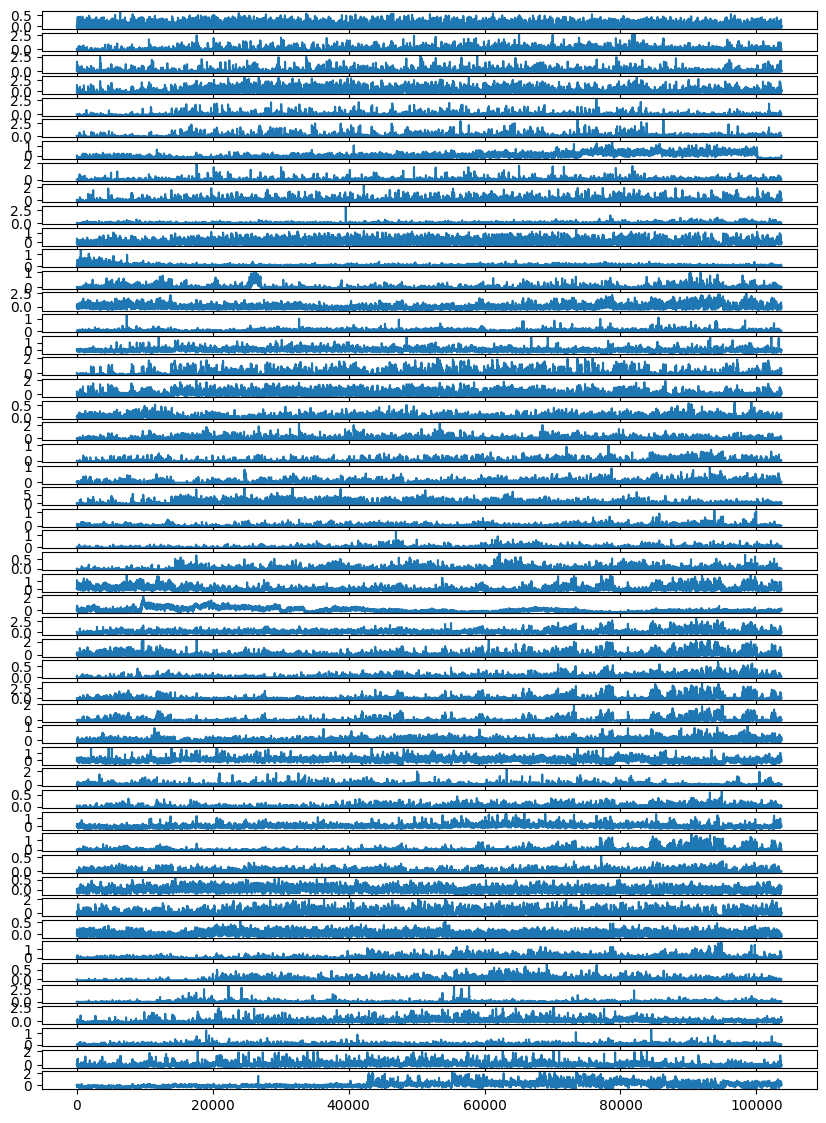

In [5]:
fig, ax = plt.subplots(50, 1, figsize=(10, 14))
for i in range(50):
    ax[i].plot(spike_counts[i])

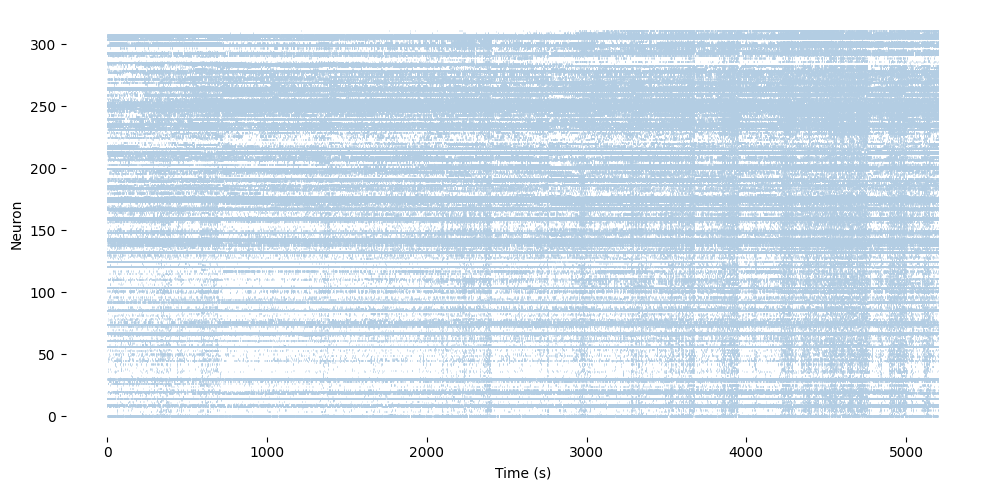

In [6]:
cmap = mpl.colormaps["Pastel1"]
color = cmap(1)
plt.figure(figsize=(10, 5))
plt.eventplot(spikes, linewidths=0.5, colors=color) 
plt.xlabel("Time (s)")
plt.ylabel("Neuron")

# convert x-axis from ms to s 
# ticks = plt.xticks()[0][1:-1]
# plt.xticks(ticks, labels=[f'{tick / 1000.0}' for tick in ticks]) 

# hide the right and top spines
plt.gca().spines["right"].set_visible(False)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["left"].set_visible(False)
plt.gca().spines["bottom"].set_visible(False)
plt.tight_layout()

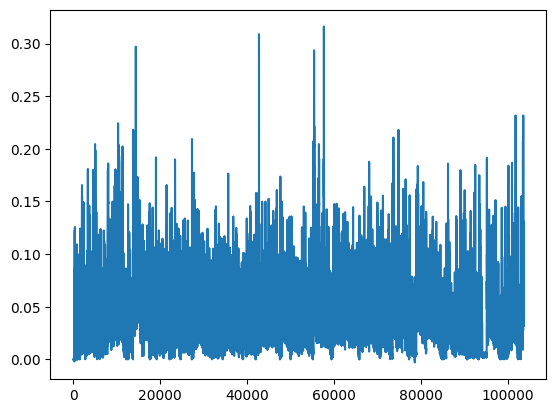

In [7]:
plt.plot(neuromod_activity)

### Create baseline training and test data 

In [8]:
"""
stimulus array contains 9 variables
stimulus 0 - tone 1
stimulus 1 - tone 2
stimulus 2 - tone 3
stimulus 3 - white noise 
stimulus 4 - airpuff 
stimulus 5 - 5% sucrose 
stimulus 6 - 10% sucrose 
stimulus 7 - quinine
stimulus 8 - odor 
"""
def get_block(spike_counts, neuromod_activity, t_start, t_end):
    block_dur = int((t_end - t_start) / bin_size)
    block_start_idx = int(t_start / bin_size) 
    spike_counts_block = spike_counts[:, block_start_idx:block_start_idx + block_dur]
    s_block = neuromod_activity[block_start_idx:block_start_idx + block_dur]
    return spike_counts_block, s_block 

def get_trial_blocks(trial_type):
    trial_times = trials_df[trials_df['trialtype'] == trial_type]['t'].astype('int').to_list()
    trial_blocks = []
    for t in trial_times:
        t_start, t_end = t - 10, t + 10
        trial_blocks.append([t_start, t_end])
    return trial_blocks

def get_white_noise_trial(cs):
    trial_dur = 6
    stim_arr_white_noise = np.zeros((9, int(trial_dur / bin_size),))
    trial_start = cs 
    pip_dur = 100 
    pip_interval = 200 
    stim_idx = 0
    for i in range(20):
        stim_arr_white_noise[3, int(stim_idx + pip_dur / (bin_size * 1000))] = 1.0 
        stim_idx += int(pip_dur / (bin_size * 1000)) + int(pip_interval / (bin_size * 1000))
    return stim_arr_white_noise

def get_airpuff_trial(cs, us):
    trial_dur = 13.5 # 13.5 seconds 
    tone_dur = 100 # 100 ms  
    airpuff_dur = 100 # 100 ms 
    airpuff_interval = 100 # 100 ms 
    tone_interval = 900 
    
    stim_arr_airpuff = np.zeros((9, int(trial_dur / bin_size),))
    stim_idx = 0
    for i in range(10):
        stim_arr_airpuff[2, int(stim_idx):int(stim_idx + tone_dur / (bin_size * 1000))] = 1.0
        stim_idx += int(tone_dur / (bin_size * 1000)) + int(tone_interval / (bin_size * 1000))
    # now add the unconditioned stimulus 
    stim_idx = (us - cs) / bin_size 
    for i in range(15):
        stim_arr_airpuff[4, int(stim_idx):int(stim_idx + airpuff_dur / (bin_size * 1000))] = 1.0 
        stim_idx += int(airpuff_dur / (bin_size * 1000)) + int(airpuff_interval / (bin_size * 1000))
    return stim_arr_airpuff

def get_reward_block(block_idx):
    block_start_idx = 7 * block_idx 
    trial_dur = 215 # 215s
    tone_dur = 1000 # 1000 ms
    lag_dur = 500 # 500 ms
    reward_dur = 2000 # 2000

    stim_arr_reward = np.zeros((9, int(trial_dur / bin_size),))
    trial_blocks = []
    # Add 4 trials of reward 1
    reward_1_us = trials_df[trials_df['trialtype'] == 'TONE_1_LAG_500_REW_1_LAG_2000_VACUUM_1']['cs'].to_list()[block_start_idx:block_start_idx + 7]
    for i in range(4):
        tone_1_onset = reward_1_us[i]
        trial_start = (tone_1_onset - reward_1_us[0]) // bin_size
        stim_idx = int(trial_start)
        # Add 1s tone 
        stim_arr_reward[0, stim_idx:int(stim_idx + tone_dur / (bin_size * 1000))] = 1.0
        stim_idx += int(tone_dur / (bin_size * 1000)) + int(lag_dur / (bin_size * 1000))
        # Provide reward 
        stim_arr_reward[5, stim_idx:int(stim_idx + reward_dur / (bin_size * 1000))] = 1.0
        trial_blocks.append([trial_start, int(stim_idx + reward_dur / (bin_size * 1000))])
        
    # omission (tone without reward)
    omission_onset = trials_df[trials_df['trialtype'] == 'TONE_1_LAG_2500']['cs'].to_list()[block_idx]
    trial_start = (omission_onset - reward_1_us[0]) / bin_size 
    stim_idx = int(trial_start) 
    stim_arr_reward[0, stim_idx:int(stim_idx + tone_dur / (bin_size * 1000))] = 1.0
    trial_blocks.append([trial_start, int(stim_idx + tone_dur / (bin_size * 1000))])

    # reward 2 
    reward_2_us = trials_df[trials_df['trialtype'] == 'TONE_1_LAG_500_REW_2_LAG_2000_VACUUM_1']['cs'].to_list()[block_idx*3:block_idx*3 +3]
    for i in range(3):
        trial_start = (reward_2_us[i] - reward_1_us[0]) // bin_size 
        stim_idx = int(trial_start)
        stim_arr_reward[0, stim_idx:int(stim_idx + tone_dur / (bin_size * 1000))] = 1.0
        stim_idx += int(tone_dur / (bin_size * 1000)) + int(lag_dur / (bin_size * 1000))
        # provide 10% sucrose drop 
        stim_arr_reward[6, stim_idx:int(stim_idx + reward_dur / (bin_size * 1000))] = 1.0 
        stim_idx += reward_dur / (bin_size * 1000)
        trial_blocks.append([trial_start, int(stim_idx)])
        
    # quinine 
    quinine_onset = trials_df[trials_df['trialtype'] == 'TONE_1_LAG_500_REW_3_LAG_2000_VACUUM_1']['cs'].to_list()[block_idx]
    trial_start = (quinine_onset - reward_1_us[0]) / bin_size
    stim_idx = int(trial_start)
    stim_arr_reward[0, stim_idx:int(stim_idx + tone_dur / (bin_size * 1000))] = 1.0
    stim_idx += int(tone_dur / (bin_size * 1000)) + int(lag_dur / (bin_size * 1000))
    # provide quinine drop 
    stim_arr_reward[7, stim_idx:int(stim_idx + reward_dur / (bin_size * 1000))] = 1.0    
    stim_idx += int(reward_dur / (bin_size * 1000))
    trial_blocks.append([trial_start, stim_idx])

    # reward 1 again 
    for i in range(4, 7):
        tone_1_onset = reward_1_us[i]
        trial_start = (tone_1_onset - reward_1_us[0]) // bin_size
        stim_idx = int(trial_start)
        # Add 1s tone 
        stim_arr_reward[0, stim_idx:int(stim_idx + tone_dur / (bin_size * 1000))] = 1.0
        stim_idx += int(tone_dur / (bin_size * 1000)) + int(lag_dur / (bin_size * 1000))
        # Provide reward 
        stim_arr_reward[5, stim_idx:int(stim_idx + reward_dur / (bin_size * 1000))] = 1.0
        trial_blocks.append([trial_start, int(stim_idx + reward_dur / (bin_size * 1000))])
    return stim_arr_reward, trial_blocks, reward_1_us[0]



### Add post-trial baseline activity and white noise blocks for training 

In [9]:
# define training samples
x_train = None 
s_train = None 
stim_arr_train = None 

spike_counts_baseline, s_baseline = get_block(spike_counts, neuromod_activity, t_start_baseline, t_end_baseline)
x_train = [spike_counts_baseline]
s_train = [s_baseline]
stim_arr_train = [np.zeros((9, s_baseline.shape[0]))]
seq_periods = [[0, s_baseline.shape[0]]]

spike_counts_pt_baseline, s_pt_baseline = get_block(spike_counts, neuromod_activity, t_start_post_trial, t_end_post_trial)
x_train.append(spike_counts_pt_baseline)
s_train.append(s_pt_baseline)
stim_arr_train.append(np.zeros((9, s_pt_baseline.shape[0])))
seq_periods.append([seq_periods[-1][1], seq_periods[-1][1] + s_pt_baseline.shape[0]])

# get first 4 white noise blocks 
white_noise_trial_dur = 6 # 6 seconds
white_noise_trials_cs = trials_df[trials_df['trialtype'] == 'TONE_2']['cs'].to_list()[0:4] 
zero_arr = np.zeros((9, int(15 / bin_size))) 

for trial_idx, trial in enumerate(white_noise_trials_cs):
    spike_counts_white_noise, s_white_noise = get_block(spike_counts, neuromod_activity, trial - 15, trial + white_noise_trial_dur + 15)
    # get stimulus 
    stim_white_noise_trial = get_white_noise_trial(trial) 
    x_train.append(spike_counts_white_noise)
    s_train.append(s_white_noise) 
    stim_arr_train.append(np.hstack([zero_arr, stim_white_noise_trial, zero_arr])) 
    seq_periods.append([seq_periods[-1][1], seq_periods[-1][1] + s_white_noise.shape[0]])

# get first 3 airpuff blocks 
airpuff_trial_dur = 13.5
airpuff_trial_cs = trials_df[trials_df['trialtype'] == 'TONE_3_LAG_500_AIRPUFF_1']['cs'].to_list()[0:3]
airpuff_trial_us = trials_df[trials_df['trialtype'] == 'TONE_3_LAG_500_AIRPUFF_1']['us'].to_list()[0:3]

for trial_idx, trial in enumerate(airpuff_trial_cs):
    spike_counts_airpuff, s_airpuff = get_block(spike_counts, neuromod_activity, trial - 15, trial + airpuff_trial_dur + 15)
    us = airpuff_trial_us[trial_idx]
    stim_airpuff = get_airpuff_trial(trial, us) 

    x_train.append(spike_counts_airpuff)
    s_train.append(s_airpuff) 
    stim_arr_train.append(np.hstack([zero_arr, stim_airpuff, zero_arr])) 
    seq_periods.append([seq_periods[-1][1], seq_periods[-1][1] + s_airpuff.shape[0]])

# get first 4 reward blocks
# fig, ax = plt.subplots(4, 1, figsize=(10, 15))

for i in range(4):
    # get stimuli 
    stim_arr_rewards, trial_blocks, reward_trial_start = get_reward_block(i)
    spike_counts_reward, s_reward = get_block(spike_counts, neuromod_activity,reward_trial_start - 15, reward_trial_start + 215 + 15)
    # s_reward = (s_reward - s_reward.min()) / (s_reward.max() - s_reward.min()) 
    
    x_train.append(spike_counts_reward)
    s_train.append(s_reward)
    stim_arr_train.append(np.hstack([zero_arr, stim_arr_rewards, zero_arr]))
    seq_periods.append([seq_periods[-1][1], seq_periods[-1][1] + s_reward.shape[0]])
    # if i == 1:
    #     ax[0].plot(s_reward[:500])
    #     ax[0].plot(temp_arr[0, :500])
    #     ax[0].plot(temp_arr[5, :500])
    #     ax[1].plot(s_reward)
    #     ax[1].plot(temp_arr[0])
    #     ax[1].plot(temp_arr[5])
x_train = np.hstack(x_train)
s_train = np.hstack(s_train) 
stim_arr_train = np.hstack(stim_arr_train) 

# normalize neuromdoulators 
s_train = (s_train - s_train.min()) / (s_train.max() - s_train.min())

In [ ]:
seeds = np.arange(0, 10)
for seed in seeds:
    torch.manual_seed(seed)
    np.random.seed(seed)
    
    rank, N = 20, spike_counts.shape[0]
    
    seq_periods_eval = []
    
    task_params = {
        "dur": 100,
        "n_trials": 3000,
        "name": "",
        "dataset_name": data_dir,
    }
    
    task = DTTDataset(task_params, 
                        x_train.T, 
                        s_train=s_train, 
                        s_test=s_train,
                        stim=stim_arr_train,
                        seq_periods=seq_periods,
                        seq_periods_eval=seq_periods_eval,
                        data_eval=spike_counts_pt_baseline.T)
    
    enc_params = {"obs_grad": True, "init_scale": 0.1}
    
    # initialise prior
    rnn_params = {
        "clipped": True,
        "train_noise_x": True,  # False
        "train_noise_z": True,
        "train_noise_z_t0": True,
        "init_noise_z": 0.1,
        "init_noise_z_t0": 1,
        "init_noise_x": 0.1,
        "scalar_noise_z": "Cov",
        "scalar_noise_x": False,
        "scalar_noise_z_t0": "Cov",
        "identity_readout": True,
        "activation": "relu",
        "exp_par": True,
        "shared_tau": 0.9,
        "readout_rates": "currents",
        "train_obs_bias": False,
        "train_obs_weights": False, #True
        "train_latent_bias": False,
        "train_neuron_bias": True,
        "orth": False,
        "m_norm": False,
        "weight_dist": "uniform",
        "weight_scaler": 1,  # /dim_N,
        "initial_state": "trainable",
        "out_nonlinearity": "identity",# "softplus",
        "neuromodulation": neuromodulation, 
        "train_nm_params": True
    }
    # initialise training parameters
    training_params = {
        "smooth_at_eval": 200,
        "run_eval": False,
        "t_forward": 0,
        "lr": 1e-3,
        "step_size": 1, 
        "gamma": 0.998849,
        "lr_end": 1e-4,
        "n_epochs": 300,
        "grad_norm": 10,
        "eval_epochs": 10,
        "batch_size": bs,
        "cuda": True,
        "smoothing": 20,
        "freq_cut_off": 10000,
        "sim_obs_noise": 0,
        "sim_latent_noise": 1,
        "opt_eps": 1e-8,
        "sim_obs_noise": 0,
        "k": 64,
        "sim_v": True,
        "sim_s": sim_s,
        "loss_f": "opt_VGTF",
        "resample": "systematic",  # , multinomial or none"
        "observation_likelihood": "Gauss",  # observation likelihood,
        "neuromodulation": neuromodulation 
    }
    
    dim_x = task.data.shape[1]
    dim_z = rank
    dim_N = N
    dim_u = 9
    dim_s = 1 
    
    VAE_params = {
        "dim_x": dim_x,
        "dim_z": dim_z,
        "dim_N": dim_N,
        "dim_u": dim_u,
        "dim_s": dim_s,
        "enc_architecture": "Inv_Obs", #CNN
        "enc_params": enc_params,
        "prior_architecture": "PLRNN",
        "rnn_params": rnn_params,
        "causal": False
    }
    vae = VAE(VAE_params)
    train_VAE(vae, 
        training_params, 
        task, 
        sync_wandb=True, 
        out_dir=out_dir, 
        fname=f"nk340_{neuromodulation}_rank_{dim_z}_seed_{seed}_stim")

Neuromodulation type: additive
using clipped ReLU activation
using uniform init
weight scaler 1
Training on : cuda


Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: kaleab-belay (kaleab-belay-icm). Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


Learning rate decay factor 0.9923540961321006
epoch 1 loss: 165.8366, ll: -165.8366, ll_x: 157.4706, ll_z: -23.4956 H: 32.1752, alpha: 0.03, lr: 0.001000, N_z: 0.1000, N_x: 0.1001
epoch 2 loss: 167.3543, ll: -167.3543, ll_x: 158.9979, ll_z: -23.4911 H: 32.1614, alpha: 0.03, lr: 0.000992, N_z: 0.1000, N_x: 0.1001
epoch 3 loss: 170.7038, ll: -170.7038, ll_x: 162.3725, ll_z: -23.4977 H: 32.1468, alpha: 0.03, lr: 0.000985, N_z: 0.1000, N_x: 0.1001
epoch 4 loss: 159.8733, ll: -159.8733, ll_x: 151.5928, ll_z: -23.5181 H: 32.1262, alpha: 0.03, lr: 0.000977, N_z: 0.1000, N_x: 0.1001
epoch 5 loss: 161.8260, ll: -161.8260, ll_x: 153.5748, ll_z: -23.5211 H: 32.1046, alpha: 0.03, lr: 0.000970, N_z: 0.1001, N_x: 0.1001
epoch 6 loss: 159.9012, ll: -159.9012, ll_x: 151.6918, ll_z: -23.5307 H: 32.0784, alpha: 0.03, lr: 0.000962, N_z: 0.1001, N_x: 0.1002
epoch 7 loss: 157.8567, ll: -157.8567, ll_x: 149.6857, ll_z: -23.5380 H: 32.0524, alpha: 0.03, lr: 0.000955, N_z: 0.1002, N_x: 0.1002
epoch 8 loss: 15

In [21]:
save_model(vae, training_params, task_params, f'all_{neuromodulation}_rank_{dim_z}_baseline', out_dir)

'../../../models/dtt/all_additive_rank_4_baseline'

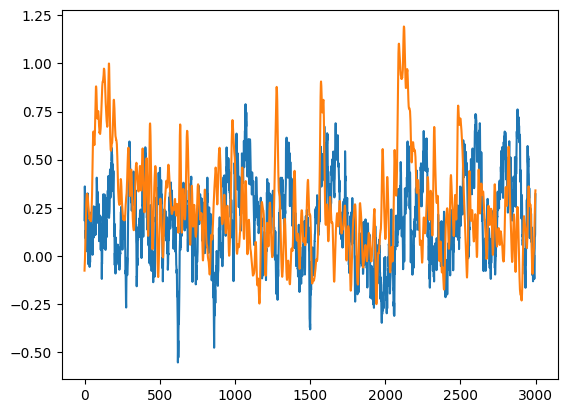

In [15]:
dev = vae.rnn.transition.Wu.device
z_hat, _, _, _ = vae.encoder(torch.from_numpy(spike_counts_pt_baseline[:, 3000:]).to(dev).to(torch.float32).unsqueeze(0))
z0 = z_hat[:, :, 0].squeeze()
Z, S = vae.rnn.get_latent_time_series(time_steps=3000, cut_off=0, z0=z0, u=torch.from_numpy(s_pt_baseline).to(torch.float32).to(dev).view(1, 1, -1), noise_scale=1, sim_v=True)
obs = vae.rnn.get_observation(Z, v=S, noise_scale=0)[0, :, :, 0]
neuron = 50
plt.plot(obs[neuron].cpu().detach())
plt.plot(spike_counts_pt_baseline[neuron, :3000])

In [17]:
from scipy.stats import pearsonr
def plot_traces(neurons, traj, spike_counts_block, neuromod_block, neuromod):
    fig, ax = plt.subplots(len(neurons) + 1, 1, figsize=(10, 14))

    for i, neuron in enumerate(neurons): 
        if i == 0:
            ax[i].plot(spike_counts_block[neuron], label='Test')
            ax[i].plot(traj[neuron].detach(), label='Gen')
        else:
            ax[i].plot(spike_counts_block[neuron])
            ax[i].plot(traj[neuron].detach())
        ax[i].set_title(f'R: {pearsonr(spike_counts_block[neuron], traj[neuron].detach())[0]}')
    handles, labels = [], []
    for axis in ax:  # Loop through all axes
        h, l = axis.get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)
    ax[-1].plot(neuromod_block)
    ax[-1].set_title('Norepinephrine')
    plt.tight_layout()
    plt.title(f'{neuromod} Traces')
    fig.legend(handles, labels)
    # fig.savefig('presynaptic.png')

/tmp/ipykernel_339748/2223582886.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  ax[i].set_title(f'R: {pearsonr(spike_counts_block[neuron], traj[neuron].detach())[0]}')


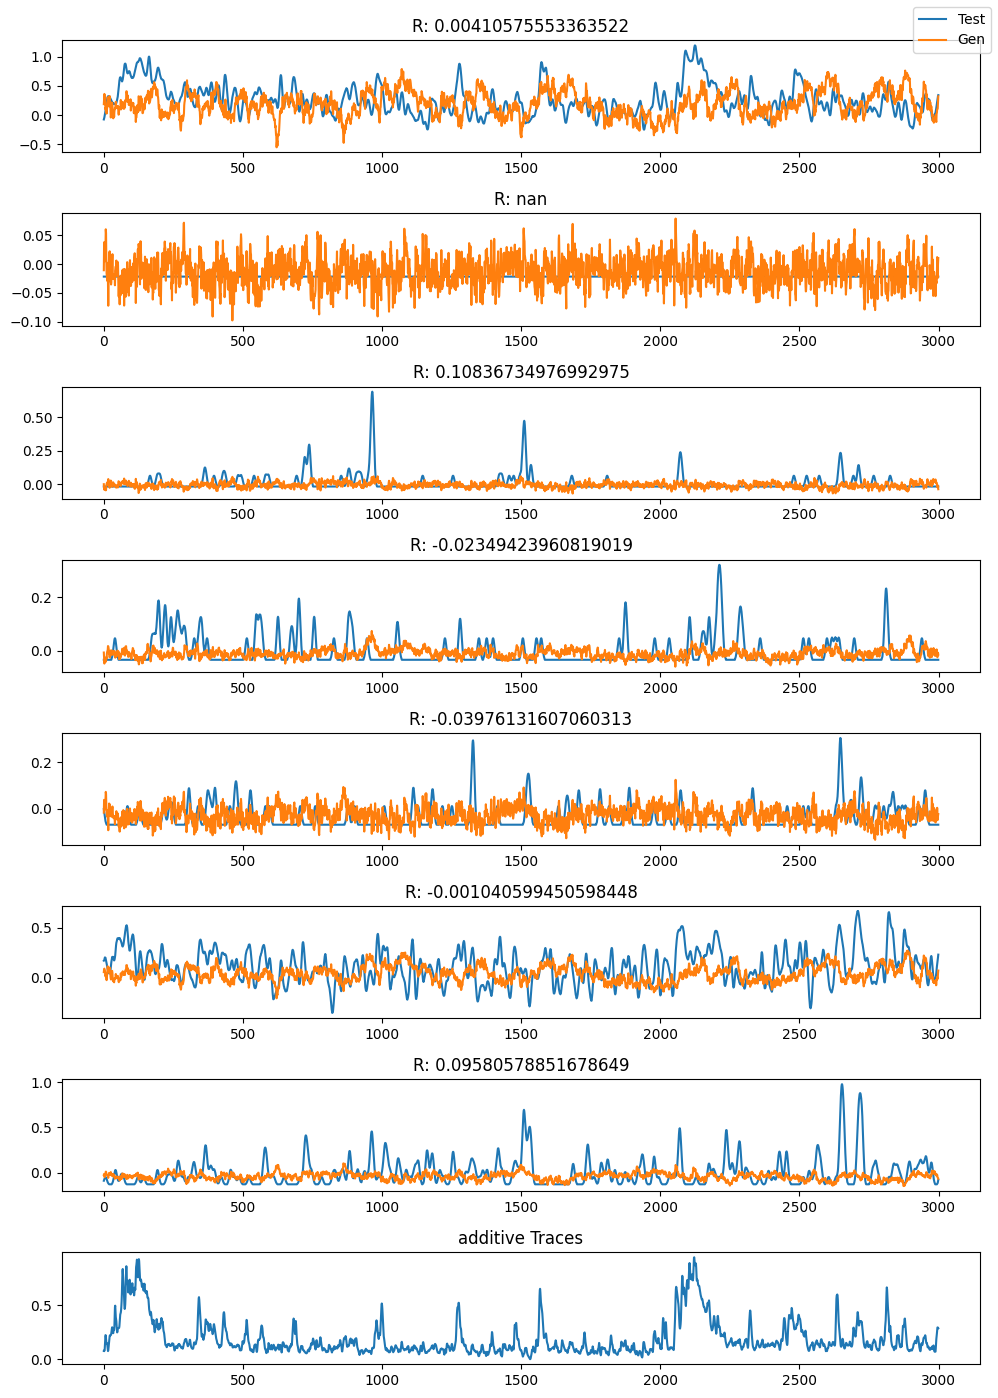

In [18]:
neurons = [50, 15, 30, 40, 80, 90, 10]
plot_traces(neurons, obs.detach().cpu(), spike_counts_pt_baseline[:, :3000], s_pt_baseline[:3000], 'additive')

In [28]:
task.n_trials, 12000 / 256

(12000, 46.875)

In [28]:
kf = KFold(n_splits=10, shuffle=False)
for fold, (train_idx, test_idx) in enumerate(kf.split(s_pt_baseline), start=1):
    if fold >1: continue 
    block_1 = train_idx[train_idx < test_idx[0]]
    block_2 = train_idx[train_idx > test_idx[-1]]
    print(f'Fold: {fold}')
    seq_periods_eval = [[test_idx[0], test_idx[-1]]]
    test_samples = spike_counts_pt_baseline[:, test_idx[0]:test_idx[-1]]
    s_test = s_pt_baseline[test_idx[0]:test_idx[-1]]

    if len(block_1) > 0 and len(block_2) > 0:
        seq_periods = [[block_1[0], block_1[-1]], [block_2[0], block_2[-1]]]
        train_samples = np.hstack([spike_counts_pt_baseline[:, block_1[0]:block_1[-1]],
                                   spike_counts_pt_baseline[:, block_2[0]:block_2[-1]]])
    elif len(block_1) > 0: 
        seq_periods = [[block_1[0], block_1[-1]]]
    else: 
        seq_periods = [[block_2[0], block_2[-1]]]
        
    print(f'Train blocks: {seq_periods}')
    print(f'Test blocks: {seq_periods_eval}')

    task_params = {
        "dur": 100,
        "n_trials": 3000,
        "name": "",
        "dataset_name": data_dir,
    }

    task = DTTDataset(task_params, 
                        spike_counts_pt_baseline.T, 
                        s_train=s_pt_baseline, 
                        s_test=s_test,
                        seq_periods=seq_periods,
                        seq_periods_eval=seq_periods_eval,
                        data_eval=test_samples.T)
  
block_start, block_end = seq_periods_eval[0]
T, dim_x = task.data_eval.shape
z_hat, _, _, _ = vae.encoder(task.data_eval[:, :].T.unsqueeze(0))
z0 = z_hat[:, :, :1].squeeze() 
Z, S = vae.rnn.get_latent_time_series(time_steps=T, cut_off=0, z0=z0, noise_scale=1, s=task.s_test.unsqueeze(0), sim_v=False, sim_s=True)
obs = vae.rnn.get_observation(Z, s=S, noise_scale=0)[0, :, :, 0]
compute_KL_divergence(obs.unsqueeze(0), task.data[block_start:block_end, :].unsqueeze(0))
# get spikes 
# lmd = vae.rnn.get_observation(Z, s=S, noise_scale=0)[0, :, :, 0]
# spikes_pred = torch.poisson(lmd).T.detach()

Fold: 1
Train blocks: [[2380, 23799]]
Test blocks: [[0, 2379]]
no input
n outliers: 1.0


nan

Text(0.5, 1.0, 'Spikes from BLA')

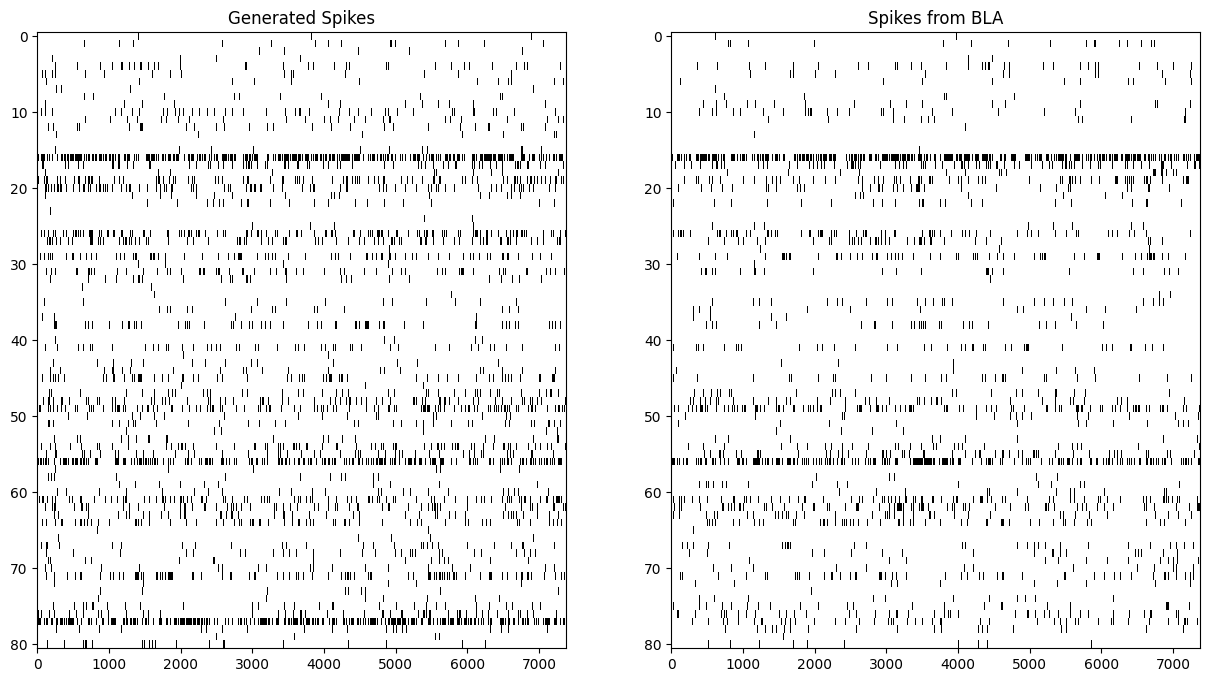

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(15, 8))
ax[0].imshow(spikes_pred.T.cpu(), aspect='auto', cmap='Greys', interpolation="none", vmax=1)
ax[1].imshow(task.data_eval[:T, :].T.cpu(), aspect='auto', cmap='Greys', interpolation='none', vmax=1)

ax[0].set_title('Generated Spikes')
ax[1].set_title('Spikes from BLA')

Text(0.5, 1.0, 'Spikes from BLA')

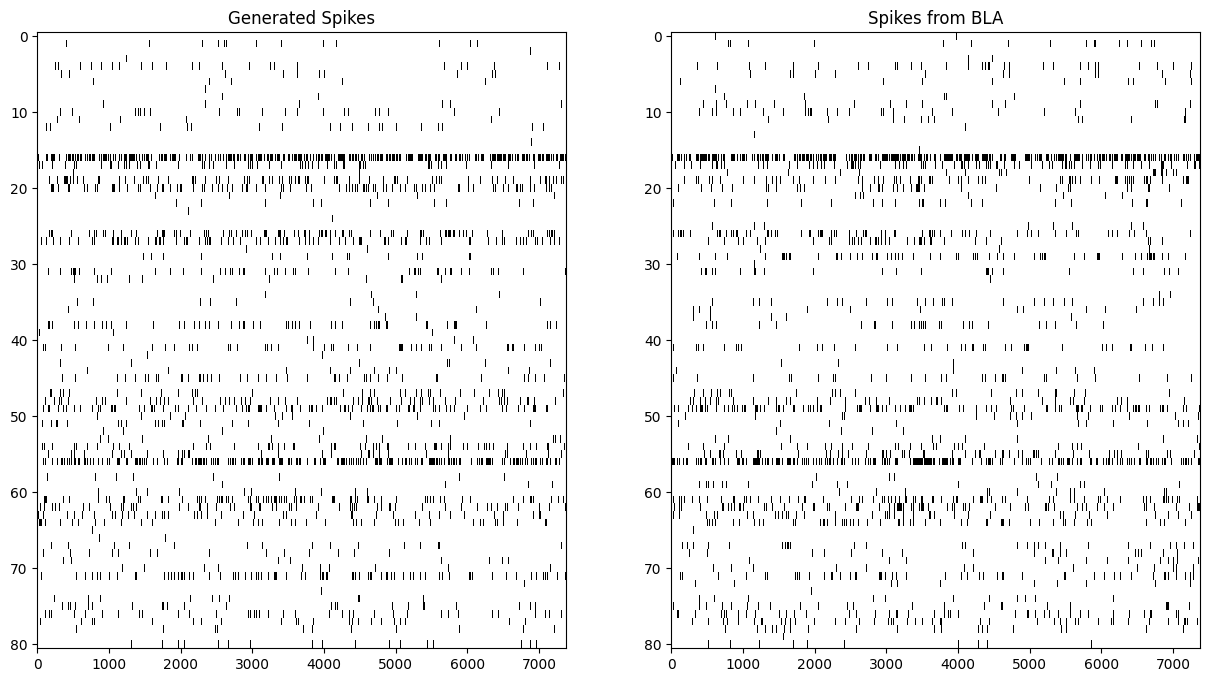

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(15, 8))
ax[0].imshow(spikes_pred.T.cpu(), aspect='auto', cmap='Greys', interpolation="none", vmax=1)
ax[1].imshow(task.data_eval[:T, :].T.cpu(), aspect='auto', cmap='Greys', interpolation='none', vmax=1)

ax[0].set_title('Generated Spikes')
ax[1].set_title('Spikes from BLA')

Text(0.5, 1.0, 'Spikes from BLA')

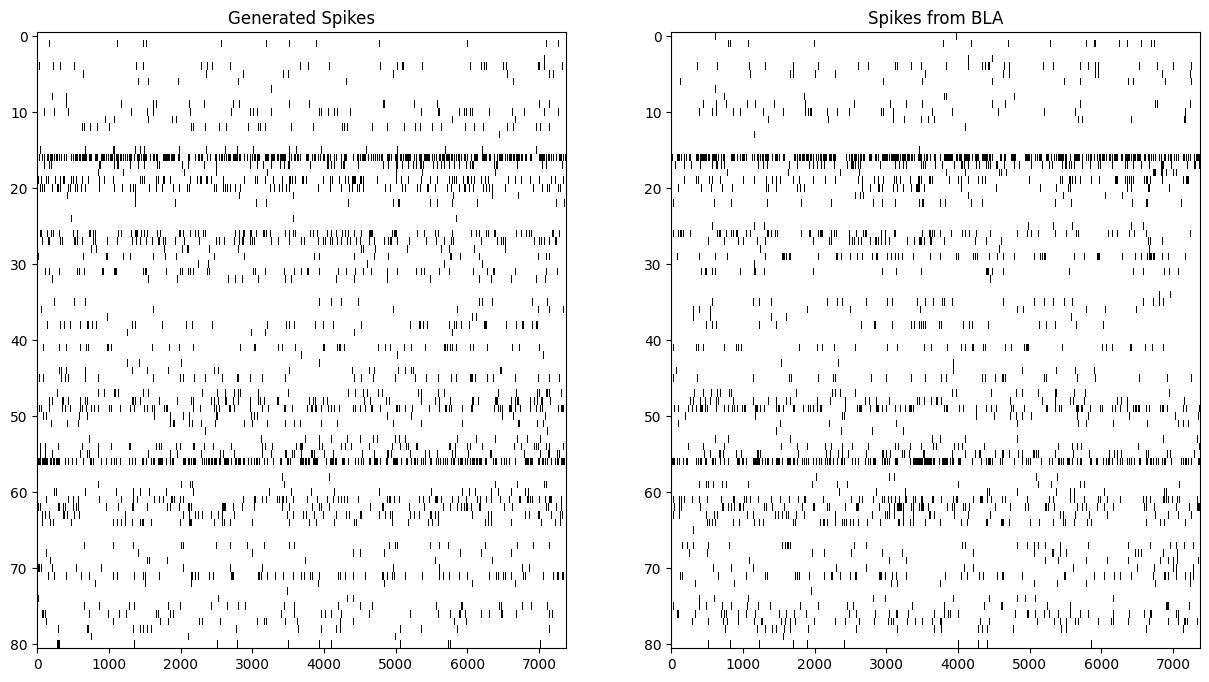

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(15, 8))
ax[0].imshow(spikes_pred.T.cpu(), aspect='auto', cmap='Greys', interpolation="none", vmax=1)
ax[1].imshow(task.data_eval[:T, :].T.cpu(), aspect='auto', cmap='Greys', interpolation='none', vmax=1)

ax[0].set_title('Generated Spikes')
ax[1].set_title('Spikes from BLA')

In [15]:
CVs_isi_test, Means_isi_test, Std_isi_test = calc_isi_stats(task.data_eval[:T, :], dt=bin_size)
CVs_isi_gen, Means_isi_gen, Std_isi_gen = calc_isi_stats(spikes_pred, dt=bin_size)

Text(0.5, 1.0, 'Scatter plots of mean ISIs of test and generated samples')

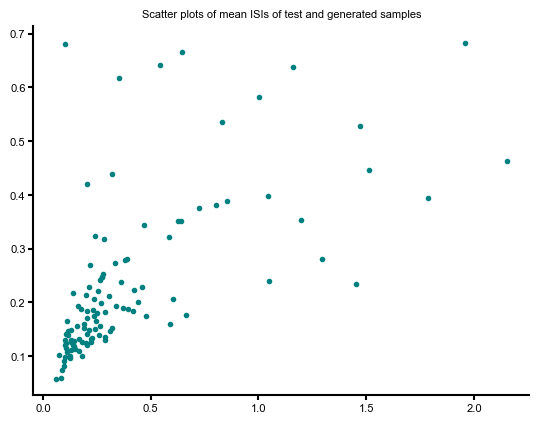

In [16]:
plt.scatter(Means_isi_gen, Means_isi_test, c='teal')
# plt.xlim([0, 4])
# plt.ylim([0, 4])
plt.title('Scatter plots of mean ISIs of test and generated samples')

Text(0.5, 1.0, 'Scatter plots of mean firing rates of test and generated samples')

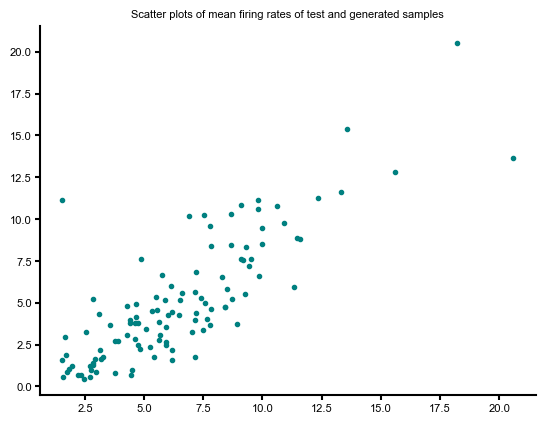

In [17]:
fr_test = torch.mean(task.data_eval[:T, :].T, axis=1) / bin_size
fr_gen = torch.mean(spikes_pred.T, axis=1) / bin_size 
plt.scatter(fr_test, fr_gen, c='teal')
# plt.xlim([0, 4])
# plt.ylim([0, 4])
plt.title('Scatter plots of mean firing rates of test and generated samples')

In [18]:
# Parameters
tau = 8  # Decay time constant

# Compute Van Rossum Distances 
vrds = np.zeros((spikes_pred.shape[1],))
for j in range(spikes_pred.shape[1]):
    vrd = van_rossum_distance(spikes_pred[:, j], task.data_eval[:, j], tau, T)
    vrds[j] = vrd 

In [22]:
np.mean(vrds), np.sum(vrds)

(21.422234754935243, 2377.868057797812)

In [20]:
np.mean(vrds), np.sum(vrds)

(21.226647551516287, 2356.157878218308)

In [18]:
np.mean(vrds), np.sum(vrds)

(21.12073954970556, 2344.4020900173173)

In [19]:
np.mean(vrds), np.sum(vrds)

(20.57248971058901, 2283.54635787538)

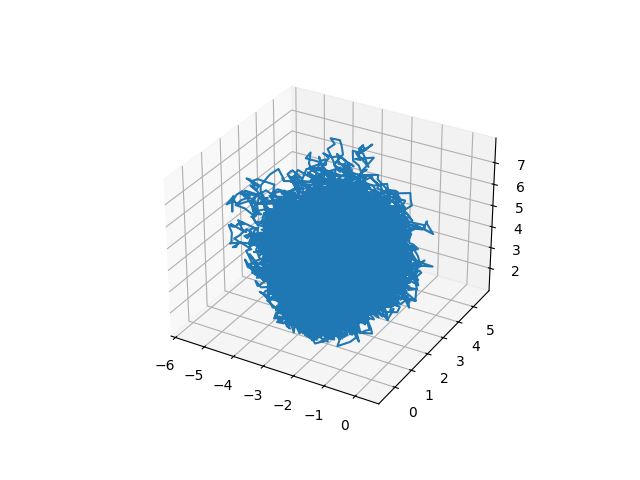

In [21]:
%matplotlib ipympl
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(Z[0, 0, :, 0], Z[0, 1, :, 0], Z[0, 2, :, 0])

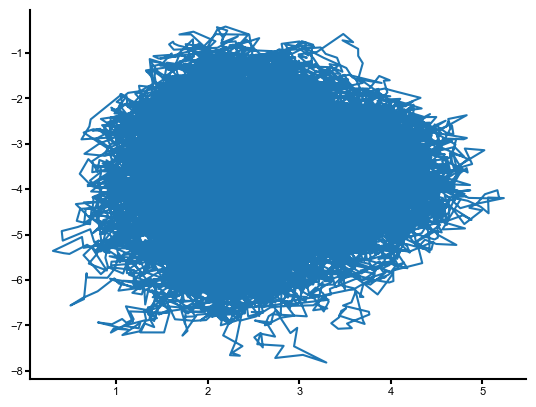

In [17]:
plt.plot(Z[0, 0, :, 0], Z[0, 1, :, 0])

In [24]:
def extract_phase_plane_vae(vae, xlims, ylims, n_points=100, h=10, inp=None, nonlinearity='relu'):
    """Extract the phase plane of the vae.rnn.
    Args:
        vae: VAE, VAE model
        xlims: float, limits for x-axis
        ylims: float, limits for y-axis
        n_points: int, number of points to sample
        h: float, step size (in ms)
    Returns:
        X: np.array (n_points x n_points), x-axis meshgrid
        Y: np.array (n_points x n_points), y-axis meshgrid
        u: np.array (n_points x n_points), x-axis velocity field
        v: np.array (n_points x n_points), y-axis velocity field
        norm: np.array (n_points x n_points), norm of the velocity field"""
    prior = vae.rnn.transition
    decay = prior.cast_A(prior.AW).detach().numpy().squeeze()
    V = (prior.n * prior.scaling).detach().numpy()
    U = prior.m_transform(prior.m).detach().numpy()
    B = prior.h.detach().numpy()
    if inp is None:
        I = np.zeros(1)
        inp = np.zeros(1)
    else:
        I = prior.Wu.detach().numpy()

    if not isinstance(xlims, list):
        xlims = [-xlims, xlims]
    if not isinstance(ylims, list):
        ylims = [-ylims, ylims]

    def dyn_eq(x, y):
        z = np.array([x, y])
        if nonlinearity == 'relu':
            zn = (decay) * z + V @ np_relu(U @ z - B + I @ inp)
        elif nonlinearity == 'clipped_relu': 
            zn = (decay) * z + V @ (np_relu(U @ z + B + I @ inp) - np_relu(U @ z + I @ inp))
            
        dz = (zn - z) / h
        return dz[0], dz[1]

    X, Y = np.meshgrid(
        np.linspace(xlims[0], xlims[1], n_points),
        np.linspace(ylims[0], ylims[1], n_points),
    )
    u, v = np.zeros_like(X), np.zeros_like(X)
    NI, NJ = X.shape

    norm = np.zeros((NI, NJ))
    for i in range(NI):
        for j in range(NJ):
            x, y = X[i, j], Y[i, j]
            dx, dy = dyn_eq(x, y)
            u[i, j] = dx
            v[i, j] = dy
            norm[i, j] = np.log(np.linalg.norm([dx, dy]))
    return X, Y, u, v, norm

In [25]:
# Extract phase planes
xlims = 15
ylims = 15
X, Y, u, v, norm = extract_phase_plane_vae(vae, xlims, ylims, n_points=2000, nonlinearity='clipped_relu')

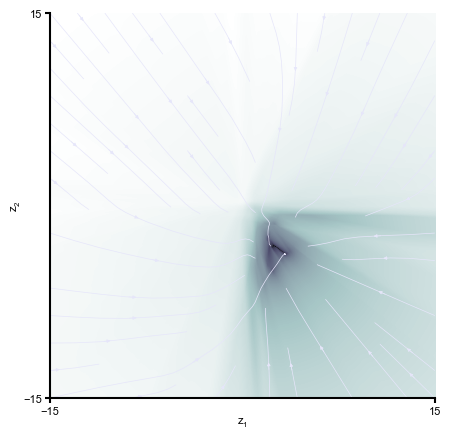

In [28]:
import matplotlib as mpl
    # Make panel A
with mpl.rc_context(fname="matplotlibrc"):
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))

    ax.imshow(
        norm,
        extent=[-xlims, xlims, -ylims, ylims],
        origin="lower",
        cmap="bone",
        vmax=np.max(norm),
        aspect="auto",
    )
    ax.streamplot(
        X, Y, u, v, color="lavender", density=0.5, linewidth=0.5, arrowsize=0.5
    )
    ax.set_box_aspect(1)
    ax.spines[["right", "top"]].set_visible(False)

    ax.set_xlim(-xlims, xlims)
    ax.set_ylim(-ylims, ylims)
    ax.set_xticks([-xlims, xlims])
    ax.set_yticks([-ylims, ylims])
    ax.set_xlabel(r"$z_1$")
    ax.set_ylabel(r"$z_2$")
    # ax.plot(Z[0, 0, :, 0], Z[0, 1, :, 0], '-o', markersize=4)  

    fig.savefig('phase_portrait.svg', format='svg')




In [18]:
from fixed_points.find_fixed_points_analytic import find_fixed_points_analytic

vae_orth = orthogonalise_network(vae)

# Get all fixed points of teacher RNN
tau, pV, pU, pB, pI = get_loadings(vae_orth)

# Get all fixed points of student RNN
D_list, D_inds, z_list, n_inverses = find_fixed_points_analytic(
    np.array([tau, tau, tau, tau]), pV, pU, 0, pB
)

TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

In [15]:
from fixed_points.find_fixed_points_analytic import find_fixed_points_analytic

vae_orth = orthogonalise_network(vae)

# Get all fixed points of teacher RNN
tau, pV, pU, pB, pI = get_loadings(vae_orth)

# Get all fixed points of student RNN
D_list, D_inds, z_list, n_inverses = find_fixed_points_analytic(
    np.array([tau]), pV, pU, 0, pB
)

120
2
(240, 120)
(121, 120)
Found a fixed point
[-34.90024948]
Done, found 1 fixed points
